In [1]:
import sys
import os 
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import random
import seaborn as sns
from scipy.stats import lognorm, weibull_min
random.seed(1234)

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from ChangePoint.ShiryaevRoberts_CPD import compute_SR_mean
from CondEnt.CondEnt_RFCDE import multivariate_EWS
from utils import plot_SR_synthetic_data


## Penalty for tail dependences

1. let 

$$X_t = \begin{equation*}
    \begin{cases}
      aY_{t-1} + (1 - \sqrt{\lambda}_t) \xi_t\\
      b + \xi_t
    \end{cases}\
\end{equation*}, 

\xi_t \sim \mathcal{N}(0,\sigma_{\xi}^2)$$

2. Here $\lambda_t$ - penalty for closeness to median:

    I. compute the deviations from median:

    $ d^Y_t = Y_t - med(Y)$

    II. Scale deviations using MinMax scaling.

    $\lambda_t = \dfrac{|d^Y_t - min(d^Y)|}{|max(d^Y) - min(d^Y)|} \in [0,1]$


In [2]:
X_train = pd.DataFrame({
    'X': np.zeros(1000),
    'Y': weibull_min.rvs(c=1.5, size=1000),
    'Z': lognorm.rvs(size=1000, s=0.35)
})

median_Y = np.median(X_train['Y'])
median_Z = np.median(X_train['Z'])

# compute abs for deviations
diff_Y = np.abs(X_train['Y'] - median_Y)
diff_Z = np.abs(X_train['Z'] - median_Z)

# scaled deviations
lambda_ = (diff_Y - np.min(diff_Y)) / (np.max(diff_Y) - np.min(diff_Y))
nu_ = (diff_Z - np.min(diff_Z)) / (np.max(diff_Z) - np.min(diff_Z))

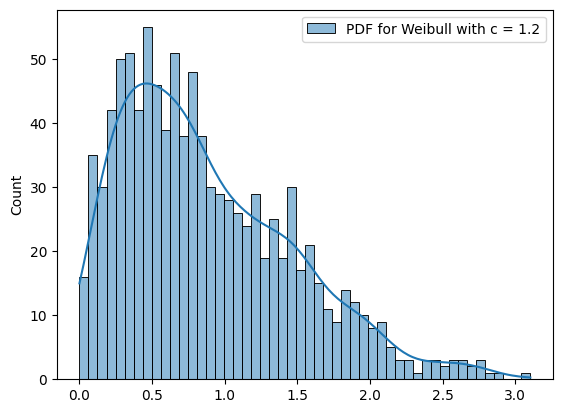

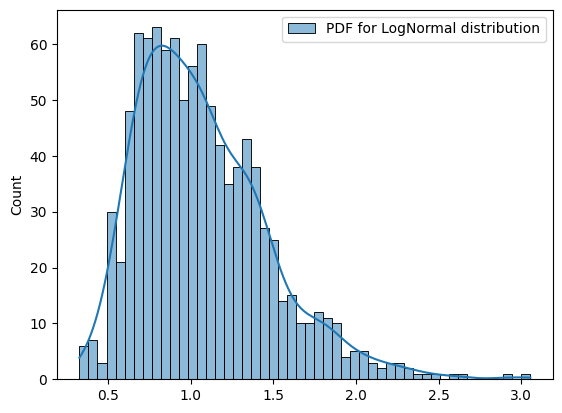

In [3]:
sns.histplot(weibull_min.rvs(c = 1.5, size = 1000), label = 'PDF for Weibull with c = 1.2', kde = True, bins = 50)
plt.legend()
plt.show()

sns.histplot(lognorm.rvs(size = 1000, s = 0.35), label = 'PDF for LogNormal distribution', kde = True, bins = 50)
plt.legend()
plt.show()

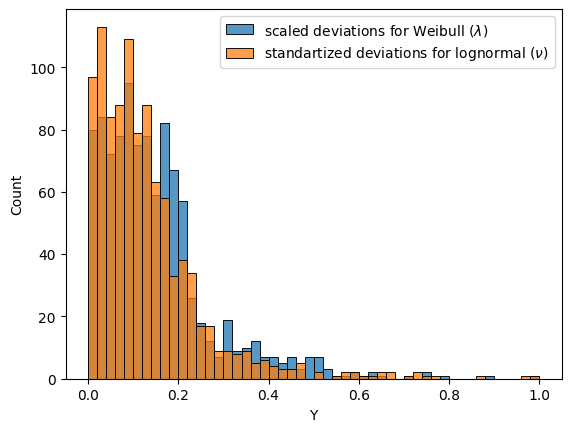

In [4]:
sns.histplot(lambda_, bins = 50, label = r'scaled deviations for Weibull ($\lambda$)')
sns.histplot(nu_, bins = 50, label = r'standartized deviations for lognormal ($\nu$)')
plt.legend()
plt.show()

In [5]:
for i in range(1, len(X_train)):
    if i < 500:
        X_train.loc[i, 'X'] = X_train['Y'][i-1] + (1-lambda_[i-1]** 0.5) * np.random.normal(0,0.5)
    else:
        X_train.loc[i, 'X'] = 0.9 + np.random.normal(0,0.5)

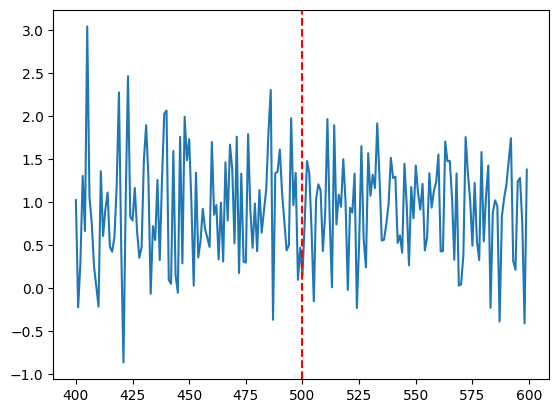

In [6]:
plt.plot(X_train['X'][400:600])
plt.axvline(500, linestyle = '--', color = 'red', label = 'changepoint')
plt.show()

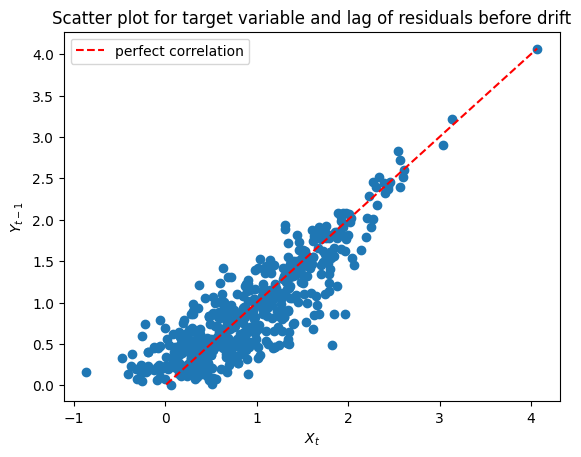

In [7]:
plt.scatter(X_train[1:500]['X'], X_train[:499]['Y'])
bisection = np.linspace(min(np.min(X_train[1:500]['X']), np.min(X_train[1:500]['Y'])),
                        max(np.max(X_train[1:500]['X']), np.max(X_train[1:500]['Y'])))
x_vals = np.linspace(np.min(X_train[1:500]['X']), np.max(X_train[1:500]['X']))
y_vals = np.linspace(np.min(X_train[1:500]['Y']), np.max(X_train[1:500]['Y']))
plt.plot(y_vals, y_vals, label = 'perfect correlation', color = 'red', linestyle = '--')
plt.xlabel(r'$X_t$')
plt.ylabel(r'$Y_{t-1}$')
plt.title('Scatter plot for target variable and lag of residuals before drift')
plt.legend()
plt.show()

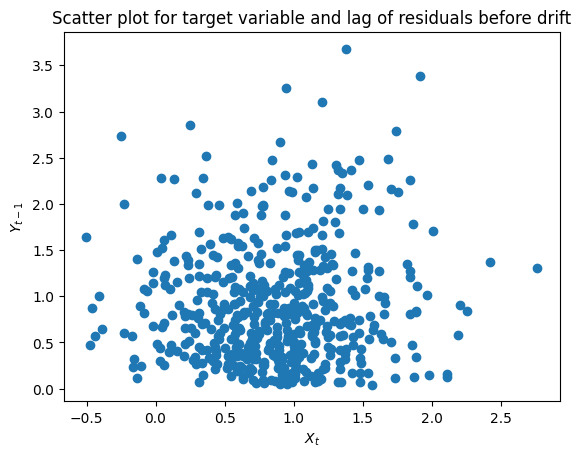

In [8]:
plt.scatter(X_train[500:]['X'], X_train[499:999]['Y'])
plt.xlabel(r'$X_t$')
plt.ylabel(r'$Y_{t-1}$')
plt.title('Scatter plot for target variable and lag of residuals before drift')
plt.show()

In [9]:
X_train = X_train.dropna()

# Define an EWS
EWS = multivariate_EWS(1)

# Define the width of sliding window
ww = 50

# Compute entropy with linear model (LR) without ranks
ent_res_lin = EWS.Est_Cond_Entropy_linear(X_train,
                                       'X',
                                      ['Y', 'Z'], 
                                      step = 1, 
                                      use_ranks=False,
                                      verbose = False, 
                                      bandwidth='auto', 
                                      n_grid=100, 
                                      n_trees=1000, 
                                      node_size=10, 
                                      window_size=ww, 
                                      n_basis=50, 
                                      fit_type='jointly')

# Compute entropy with linear model (LR) with ranks
ent_res_lin_r = EWS.Est_Cond_Entropy_linear(X_train,
                                       'X',
                                      ['Y', 'Z'], 
                                      step = 1, 
                                      use_ranks=True,
                                      verbose = False, 
                                      bandwidth='auto', 
                                      n_grid=100, 
                                      n_trees=1000, 
                                      node_size=10, 
                                      window_size=ww, 
                                      n_basis=50, 
                                      fit_type='jointly')

# Compute entropy with local linear forest (LLF) without ranks
ent_res_llf = EWS.Est_Cond_Entropy_LLF(X_train,
                                        'X',
                                        ['Y', 'Z'], 
                                        step = 1, 
                                        use_ranks=False,
                                        verbose = False, 
                                        bandwidth='auto', 
                                        n_grid=100, 
                                        n_trees_RFCDE=1000, 
                                        node_size=10, 
                                        window_size=ww, 
                                        n_basis=50, 
                                        fit_type='jointly',
                                        n_trees_LLF=1000,
                                        ll_split_weight_penalty=False,
                                        ll_split_lambda=0.2,
                                        ll_split_variables=None,
                                        ll_split_cutoff=None,
                                        equalize_cluster_weights=False,
                                        sample_fraction=0.5,
                                        min_node_size=2,
                                        honesty=True,
                                        honesty_fraction=0.15,
                                        honesty_prune_leaves=True,
                                        alpha=0.15,
                                        imbalance_penalty=0,
                                        ci_group_size=2,
                                        n_jobs=-1,
                                        seed=42,
                                        enable_tree_details=False)


# Compute entropy with local linear forest (LLF) with ranks
ent_res_llf_r = EWS.Est_Cond_Entropy_LLF(X_train,
                                        'X',
                                        ['Y', 'Z'], 
                                        step = 1, 
                                        use_ranks=True,
                                        verbose = False, 
                                        bandwidth='auto', 
                                        n_grid=100, 
                                        n_trees_RFCDE=1000, 
                                        node_size=10, 
                                        window_size=ww, 
                                        n_basis=50, 
                                        fit_type='jointly',
                                        n_trees_LLF=1000,
                                        ll_split_weight_penalty=False,
                                        ll_split_lambda=0.2,
                                        ll_split_variables=None,
                                        ll_split_cutoff=None,
                                        equalize_cluster_weights=False,
                                        sample_fraction=0.5,
                                        min_node_size=2,
                                        honesty=True,
                                        honesty_fraction=0.15,
                                        honesty_prune_leaves=True,
                                        alpha=0.15,
                                        imbalance_penalty=0,
                                        ci_group_size=2,
                                        n_jobs=-1,
                                        seed=42,
                                        enable_tree_details=False)


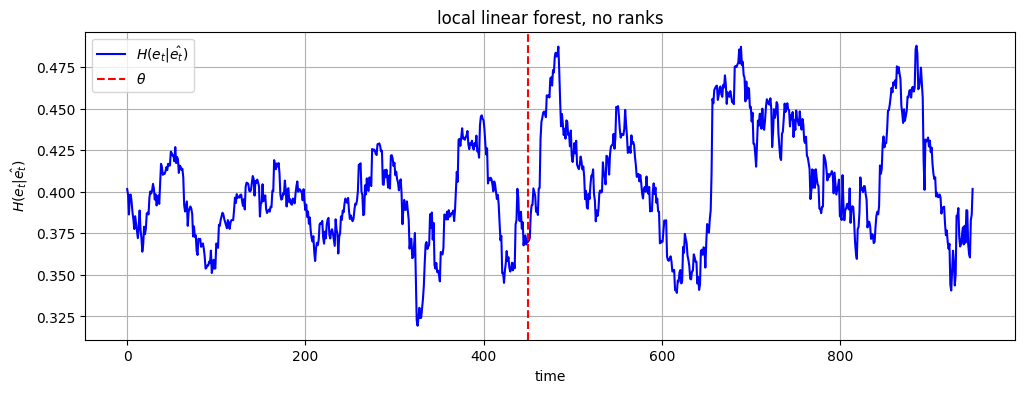

In [15]:
plt.figure(figsize = (12,4))
plt.plot(ent_res_llf, color = 'blue', label = r'$H(e_t|\hat{e_t})$')
plt.axvline(450, color = 'red', linestyle = '--', label = r'$\theta$')
plt.grid()
plt.legend()
plt.xlabel('time')
plt.ylabel(r'$H(e_t|\hat{e_t})$')
plt.title('local linear forest, no ranks')
plt.savefig('HT_LLF_NR.png')

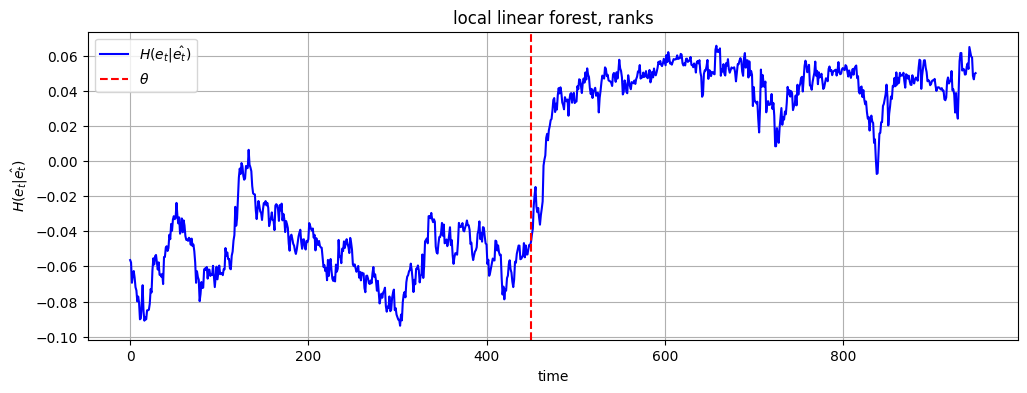

In [16]:
plt.figure(figsize = (12,4))
plt.plot(ent_res_llf_r, color = 'blue', label = r'$H(e_t|\hat{e_t})$')
plt.axvline(450, color = 'red', linestyle = '--', label = r'$\theta$')
plt.grid()
plt.legend()
plt.xlabel('time')
plt.ylabel(r'$H(e_t|\hat{e_t})$')
plt.title('local linear forest, ranks')
plt.savefig('HT_LLF_R.png')